In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

In [2]:
df = pd.read_csv("../outputs/giving_happiness_clean.csv")

In [3]:
df.shape

(10822, 53)

In [4]:
for year in [2017, 2019]:
    df[f"income_10k_{year}"] = df[f"family_income_{year}"] / 10000
    df[f"wealth_100k_{year}"] = df[f"wealth_{year}"] / 100000

In [5]:
df[
    [
        "family_income_2019",
        "income_10k_2019",
        "wealth_2019",
        "wealth_100k_2019"
    ]
].head()

,family_income_2019,income_10k_2019,wealth_2019,wealth_100k_2019
0,11028.0,1.1028,1200.0,0.012
1,60970.0,6.0970,195000.0,1.950
2,9380.0,0.9380,0.0,0.000
3,10000.0,1.0000,2000.0,0.020
4,31000.0,3.1000,14000.0,0.140


In [6]:
model_2019_scaled = smf.ols(
    "life_satisfaction_2019 ~ donor_2019 + income_10k_2019 + wealth_100k_2019 + age_2019 + education_2019 + health_status_2019",
    data=df
).fit()

print(model_2019_scaled.summary())

                              OLS Regression Results                              
Dep. Variable:     life_satisfaction_2019   R-squared:                       0.110
Model:                                OLS   Adj. R-squared:                  0.110
Method:                     Least Squares   F-statistic:                     191.9
Date:                    Thu, 17 Sep 2026   Prob (F-statistic):          2.38e-231
Time:                            14:52:01   Log-Likelihood:                -11030.
No. Observations:                    9297   AIC:                         2.207e+04
Df Residuals:                        9290   BIC:                         2.212e+04
Df Model:                               6                                         
Covariance Type:                nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------

In [9]:
model_2017_scaled = smf.ols(
    "life_satisfaction_2017 ~ donor_2017 + income_10k_2017 + wealth_100k_2017 + age_2017 + education_2017 + health_status_2017",
    data=df
).fit()

print(model_2017_scaled.summary())


                              OLS Regression Results                              
Dep. Variable:     life_satisfaction_2017   R-squared:                       0.110
Model:                                OLS   Adj. R-squared:                  0.109
Method:                     Least Squares   F-statistic:                     190.1
Date:                    Thu, 17 Sep 2026   Prob (F-statistic):          3.20e-229
Time:                            14:52:41   Log-Likelihood:                -11060.
No. Observations:                    9273   AIC:                         2.213e+04
Df Residuals:                        9266   BIC:                         2.218e+04
Df Model:                               6                                         
Covariance Type:                nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------

In [10]:
check_cols_2019 = [
    "donor_2019",
    "income_10k_2019",
    "wealth_100k_2019",
    "age_2019",
    "education_2019",
    "health_status_2019"
]

df[check_cols_2019].corr()

,donor_2019,income_10k_2019,wealth_100k_2019,age_2019,education_2019,health_status_2019
donor_2019,1.000000,0.304004,0.172073,0.290612,0.314158,-0.084681
income_10k_2019,0.304004,1.000000,0.417695,0.031858,0.319234,-0.205690
wealth_100k_2019,0.172073,0.417695,1.000000,0.163528,0.127034,-0.074123
age_2019,0.290612,0.031858,0.163528,1.000000,-0.055581,0.227677
education_2019,0.314158,0.319234,0.127034,-0.055581,1.000000,-0.227255
health_status_2019,-0.084681,-0.205690,-0.074123,0.227677,-0.227255,1.000000


In [11]:
check_cols_2017 = [
    "donor_2017",
    "income_10k_2017",
    "wealth_100k_2017",
    "age_2017",
    "education_2017",
    "health_status_2017"
]

df[check_cols_2017].corr()

,donor_2017,income_10k_2017,wealth_100k_2017,age_2017,education_2017,health_status_2017
donor_2017,1.000000,0.327317,0.197698,0.290400,0.306781,-0.091089
income_10k_2017,0.327317,1.000000,0.414468,0.060453,0.312474,-0.192703
wealth_100k_2017,0.197698,0.414468,1.000000,0.193115,0.149807,-0.079971
age_2017,0.290400,0.060453,0.193115,1.000000,-0.060052,0.226937
education_2017,0.306781,0.312474,0.149807,-0.060052,1.000000,-0.222337
health_status_2017,-0.091089,-0.192703,-0.079971,0.226937,-0.222337,1.000000


In [12]:
final_results = pd.DataFrame({
    "Year": [2017, 2019],
    "Donor coefficient": [
        model_2017_scaled.params["donor_2017"],
        model_2019_scaled.params["donor_2019"]
    ],
    "Donor p-value": [
        model_2017_scaled.pvalues["donor_2017"],
        model_2019_scaled.pvalues["donor_2019"]
    ],
    "R-squared": [
        model_2017_scaled.rsquared,
        model_2019_scaled.rsquared
    ],
    "Observations": [
        int(model_2017_scaled.nobs),
        int(model_2019_scaled.nobs)
    ]
})

final_results

,Year,Donor coefficient,Donor p-value,R-squared,Observations
0,2017,-0.076490,0.000060,0.109615,9273
1,2019,-0.048286,0.010889,0.110291,9297


In [13]:
final_results.to_csv(
    "../outputs/final_model_results.csv",
    index=False
)

In [14]:
plot_data = pd.DataFrame({
    "Year": [2017, 2019],
    "Donor": [
        df.groupby("donor_2017")["life_satisfaction_2017"].mean()[1],
        df.groupby("donor_2019")["life_satisfaction_2019"].mean()[1]
    ],
    "Non-donor": [
        df.groupby("donor_2017")["life_satisfaction_2017"].mean()[0],
        df.groupby("donor_2019")["life_satisfaction_2019"].mean()[0]
    ]
})

plot_data

,Year,Donor,Non-donor
0,2017,2.076959,2.277681
1,2019,2.074394,2.245096


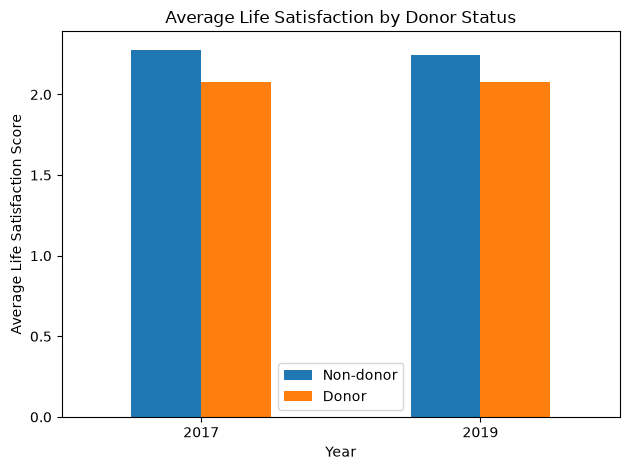

In [15]:
plot_data.set_index("Year")[["Non-donor", "Donor"]].plot(kind="bar")

plt.title("Average Life Satisfaction by Donor Status")
plt.xlabel("Year")
plt.ylabel("Average Life Satisfaction Score")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

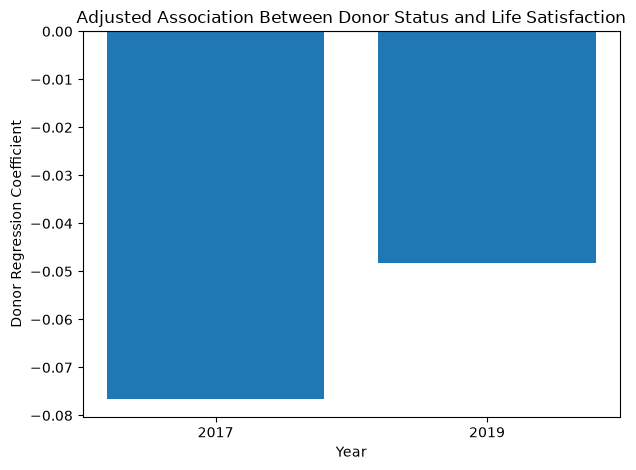

In [16]:
plt.bar(
    final_results["Year"].astype(str),
    final_results["Donor coefficient"]
)

plt.axhline(0)
plt.title("Adjusted Association Between Donor Status and Life Satisfaction")
plt.xlabel("Year")
plt.ylabel("Donor Regression Coefficient")
plt.tight_layout()
plt.show()

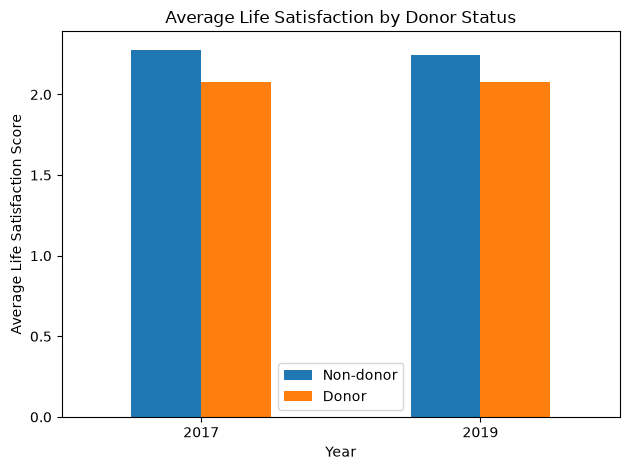

In [17]:
ax = plot_data.set_index("Year")[["Non-donor", "Donor"]].plot(kind="bar")

plt.title("Average Life Satisfaction by Donor Status")
plt.xlabel("Year")
plt.ylabel("Average Life Satisfaction Score")
plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig(
    "../outputs/life_satisfaction_by_donor.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

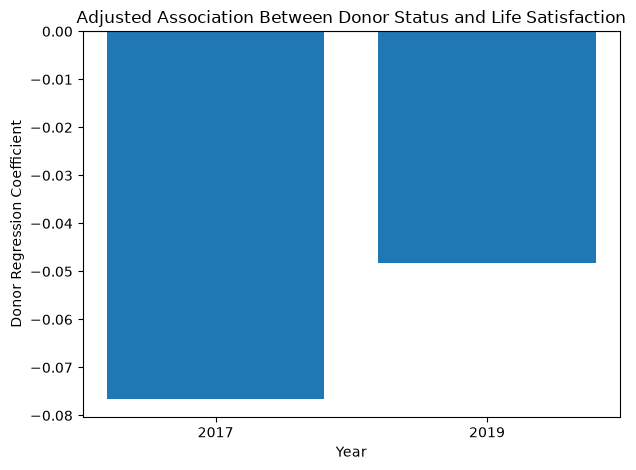

In [18]:
plt.bar(
    final_results["Year"].astype(str),
    final_results["Donor coefficient"]
)

plt.axhline(0)
plt.title("Adjusted Association Between Donor Status and Life Satisfaction")
plt.xlabel("Year")
plt.ylabel("Donor Regression Coefficient")
plt.tight_layout()

plt.savefig(
    "../outputs/donor_regression_effect.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()